---
format:
  html: default
---

# A3: Newton, secant & interpolation {.unnumbered}

Assignment 3: Solving nonlinear equations in 1d and polynomial interpolation </br>
Published: <b>Wed 7 Oct</b>

<div class="alert alert-block alert-info">
<b>Note:</b>
<ul>
  <li>Complete the following and submit to Canvas before <b>Wed 14 Oct, 23:59</b>.</li>
  <li>Late work will receive 0%.</li>
  <li>Each assignment is worth the same.</li>
  <li>Please get in contact with the TA/instructor in plenty of time if you need help.</li>
  <li>Before submitting your work, make sure to check everything runs as expected. Click <b>Kernel &gt; Restart Kernel and Run All Cells</b>. Submit your notebook in .pdf format by clicking <b>File &gt; Export Notebook As &gt; PDF</b> or by printing to PDF in the browser.</li>
  <li>Feel free to add more cells to experiment or test your answers.</li>
  <li>I encourage you to discuss the course material and assignment questions with your classmates. However, unless otherwise explicitly stated on the assignment, you must complete and write up your solutions on your own.</li>
  <li>The use of GenAI is prohibited as outlined in the course syllabus. If suspected of cheating, you may be asked to complete a written or oral exam on the content of this assignment.</li>
</ul>
</div>

<div class="custom-lecture-buttons my-3 d-flex gap-2">
  <a href="https://raw.githubusercontent.com/jackrthomas/Math5485/main/assignments/A03.ipynb" class="btn-download-ipynb btn btn-outline-primary btn-sm" target="_blank">
    <i class="bi bi-journal-code"></i> Download (.ipynb)
  </a>
</div>

The assignment is worth **100 pts**. The symbols ✍️, 💻 indicate theory ($\LaTeX$), practice (code), respectively.

In [ ]:
Name = "YOUR NAME HERE"

The following cell contains code that you should use throughout the assignment (you do **not** need to implement Newton's method or the secant method yourself): ```Newton(f, f_prime, x1)``` and ```secant(f, x1, x2)``` are the functions from Lecture 5 (each returns the vector of iterates $x_1, x_2, \dots$) and ```order_table(x, ξ; α)``` (from A2) prints the errors $e_n := |x_n - \xi|$ together with $\frac{e_{n}}{e_{n-1}^\alpha}$ (approximating $\mu$ if the order is $\alpha$) and $\frac{\log e_{n}}{\log e_{n-1}}$ (approximating $\alpha$). 

In [1]:
using Plots, LaTeXStrings, Printf

# Newton's method x_{n+1} = x_n - f(x_n)/f'(x_n) (from Lecture 5)
function Newton(f, f_prime, x1; N=100, tol=1e-10)
    x = [x1]
    for n ∈ 2:N
        push!(x, x[n-1] - f(x[n-1])/f_prime(x[n-1]))
        if abs(f(x[end])) < tol
            return x
        end
    end
    @warn "Newton did not converge within $N iterations."
    return x
end

# secant method x_{n+1} = x_n - f(x_n)/f[x_n, x_{n-1}] (from Lecture 5)
function secant(f, x1, x2; N=100, tol=1e-10)
    x = [x1, x2]
    for n ∈ 3:N
        push!(x, x[n-1] - (x[n-1] - x[n-2])/(f(x[n-1]) - f(x[n-2])) * f(x[n-1]))
        if abs(f(x[end])) < tol
            return x
        end
    end
    @warn "secant did not converge within $N iterations."
    return x
end

# prints the errors e_n = |x_n - ξ| together with 
#   e_n / e_{n-1}^α          (\to μ if the order of convergence is α)  
#   log(e_n) / log(e_{n-1})  (\to order of convergence)
function order_table(x, ξ; α=1)
    e = @. abs(x - ξ)
    @printf("%4s %22s %12s %16s %20s\n", "n", "x_n", "e_n", "e_n/e_{n-1}^α", "log e_n/log e_{n-1}")
    @printf("%4d %22.16f %12.3e\n", 1, x[1], e[1])
    for n ∈ 2:length(x)
        @printf("%4d %22.16f %12.3e %16.6f %20.6f\n", n, x[n], e[n], e[n]/e[n-1]^α, log(e[n])/log(e[n-1]))
    end
end

order_table (generic function with 1 method)

The following theorem from lectures may be useful:

<div class='alert alert-block alert-success'><b>Theorem (Newton).</b> 

Suppose $f: [a,b] \to \mathbb R$ is twice continuously differentiable with $f(\xi) = 0$ and $f'(\xi) \not= 0$ and that $\left|\frac{f''(x)}{f'(y)}\right| \leq A$ for all $x,y \in [a,b]$. Then, $x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$ converges at least quadratically to $\xi$ for all $x_1 \in [a,b]$ with $|x_1 - \xi| \leq A^{-1}$, and the asymptotic error constant is $\mu = \frac12 \left| \frac{f''(\xi)}{f'(\xi)} \right|$.

</div>

<div style="break-after: page;"></div>

## A: Newton's method in practice [30 pts] {.unnumbered}

***Exercise 1. (Newton's method in practice)*** Consider the following functions:

\begin{align}
    f_1(x) &= x^3 - 3x - 5,       \nonumber\\
    f_2(x) &= x - \log(1+x),          \nonumber\\
    f_3(x) &= \arctan x,      \nonumber\\
    f_4(x) &= \mathrm{sign}(x) \sqrt{|x|}.          \nonumber
\end{align}

Here's a plot of these functions:

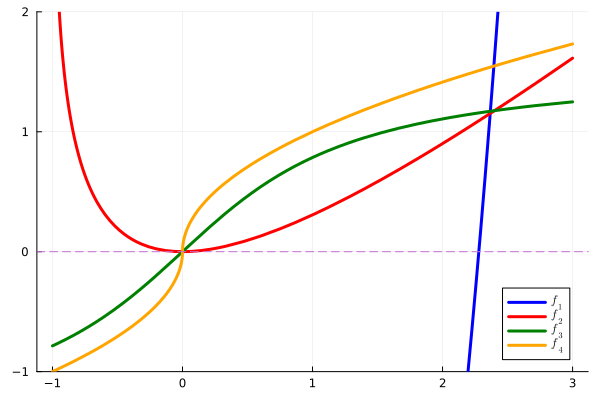

In [ ]:
f1(x) = x^3 - 3x - 5
f2(x) = x - log(1 + x)
f3(x) = atan(x)
f4(x) = sign(x) * sqrt(abs(x))

plot( f1, -1, 3; ylims=(-1,2), label=L"f_1", lw=3, color=:blue )
plot!( f2, -0.99, 3; label=L"f_2", lw=3, color=:red )
plot!( f3, -1, 3; label=L"f_3", lw=3, color=:green )
plot!( f4, -1, 3; label=L"f_4", lw=3, color=:orange )
hline!( [0], linestyle=:dash, primary=false )

<div style="break-after: page;"></div>

(i) ✍️ Show that $f_1$ has a root $\xi \in [2,3]$ and that $f_2(0) = f_3(0) = f_4(0) = 0$.

<div class='alert alert-block alert-success'><b>Answer.</b> 










</div> 

<div style="break-after: page;"></div>

(ii) $f_1$: 

💻 Run Newton's method for $f_1$ with $x_1 = 2$ using ```Newton``` and ```order_table``` from the code cell at the start of the assignment. If the iteration converges, estimate the order of convergence $\alpha$ and the asymptotic error constant $\mu$ numerically.

✍️ Find $A$ such that $\left|\frac{f_1''(x)}{f_1'(y)}\right| \leq A$ for all $x, y \in [2,3]$ and compare your numerical estimate of $\mu$ with the theoretical value $\frac12 \left| \frac{f_1''(\xi)}{f_1'(\xi)} \right|$.

In [ ]:
# your code here

<div class='alert alert-block alert-success'><b>Answer.</b> 










</div> 

<div style="break-after: page;"></div>

(iii) $f_2$: 

💻 Run Newton's method for $f_2$ with $x_1 = 0.5$ using ```Newton``` and ```order_table``` from the code cell at the start of the assignment. If the iteration converges, estimate the order of convergence $\alpha$ and the asymptotic error constant $\mu$ numerically.

✍️ Why does the convergence behaviour for $f_2$ not contradict **Theorem (Newton)** above?

In [ ]:
# your code here

<div class='alert alert-block alert-success'><b>Answer.</b> 










</div> 

<div style="break-after: page;"></div>

(iv) $f_3$: 

💻 Run Newton's method for $f_3$ with $x_1 = 0.5$ using ```Newton``` and ```order_table``` from the code cell at the start of the assignment. If the iteration converges, estimate the order of convergence $\alpha$ and the asymptotic error constant $\mu$ numerically.

✍️ For $f_3$, the convergence (from $x_1 = 0.5$) is faster than quadratic. Explain why. What happens if you instead start at $x_1 = 2$? Explain.

*Hint:* see the discussion of Kepler's equation (Example 5.5).

In [ ]:
# your code here

<div class='alert alert-block alert-success'><b>Answer.</b> 










</div> 

<div style="break-after: page;"></div>

(v) $f_4$: 

💻 Run Newton's method for $f_4$ with $x_1 = 0.5$ using ```Newton``` and ```order_table``` from the code cell at the start of the assignment. If the iteration converges, estimate the order of convergence $\alpha$ and the asymptotic error constant $\mu$ numerically.

✍️ Compute $x_{n+1}$ explicitly in terms of $x_n$. Hence show that Newton's method does not converge for any $x_1 \not= 0$. Why does this not contradict **Theorem (Newton)** above?

In [ ]:
# your code here

<div class='alert alert-block alert-success'><b>Answer.</b> 










</div> 

<div style="break-after: page;"></div>

## B: Efficiency of Newton and secant [20 pts] {.unnumbered}

The *efficiency index* of a method with order of convergence $\alpha$ requiring $\theta$ function evaluations per iteration is $E := \alpha^{1/\theta}$. (Here, evaluating $f$ or $f'$ each counts as one function evaluation.)

***Exercise 2. (Newton vs. secant)*** Let $f_1(x) = x^3 - 3x - 5$ and $\xi \in [2,3]$ be as in Exercise 1.

(i) ✍️ What is the efficiency index of Newton's method and of the secant method?

<div class='alert alert-block alert-success'><b>Answer.</b> 










</div> 

<div style="break-after: page;"></div>

(ii) 💻 Apply the secant method (```secant``` from the code cell at the start of the assignment) to $f_1$ with $x_1 = 2, x_2 = 3$. Estimate the order of convergence and compare with the theoretical values $\alpha = \frac{1 + \sqrt5}{2}$ and $\mu = \left| \frac12 \frac{f_1''(\xi)}{f_1'(\xi)} \right|^{\alpha/(1+\alpha)}$ from Lecture 5.

In [ ]:
# your code here

<div class='alert alert-block alert-success'><b>Answer.</b> 










</div> 

<div style="break-after: page;"></div>

(iii) 💻 For both Newton's method (with $x_1 = 2$) and the secant method (with $x_1 = 2, x_2 = 3$), count the total number of function evaluations needed to obtain $|x_n - \xi| < 10^{-12}$. Which method is cheaper? Is this consistent with the efficiency indices of the two methods?

*Hint:* use ```Newton``` and ```secant``` from the code cell at the start of the assignment. Both stop once $|f(x_n)| <$ ```tol``` (default $10^{-10}$), so you may need to pass a smaller tolerance, e.g. ```Newton(f, f_prime, x1; tol=1e-14)```.

In [ ]:
# your code here

<div class='alert alert-block alert-success'><b>Answer.</b> 










</div> 

<div style="break-after: page;"></div>

## C: Barycentric formula & divided differences [30 pts] {.unnumbered}

Recall from Lecture 8 that, for distinct nodes $X = \{x_0, \dots, x_n\}$, the divided differences satisfy the recursion

\begin{align}
    f[x_0, \dots, x_n] = \frac{f[x_1, \dots, x_n] - f[x_0, \dots, x_{n-1}]}{x_n - x_0}, \nonumber
\end{align}

the polynomial interpolant can be written in *Newton form* 

\begin{align}
    I_Xf(x) &= \sum_{k=0}^n f[x_0, \dots, x_k] \, \pi_k(x), \nonumber\\
    \pi_k(x) &:= (x - x_0) \cdots (x - x_{k-1}), \nonumber
\end{align}

and in *Barycentric form* 

\begin{align}
    I_Xf(x) &= \left. \sum_{j=0}^n \frac{\lambda_j f(x_j)}{x - x_j} \middle/ \sum_{j=0}^n \frac{\lambda_j}{x - x_j} \right., \nonumber\\
    %
    \lambda_j &:= \frac{1}{\prod_{k\not=j} (x_j - x_k)}. \nonumber
\end{align}

<div style="break-after: page;"></div>

***Exercise 3. (Divided differences)*** Let $f(x) = \frac1x$.

(i) ✍️ Compute the divided difference table of $f$ on $X = \{ x_0, x_1, x_2 \} = \{1, 2, 4\}$ and write down $I_Xf$ in Newton form. Now add the node $x_3 = \frac12$: update your table and write down the new interpolant. Which terms did you have to compute again?

<div class='alert alert-block alert-success'><b>Answer.</b> 










</div> 

<div style="break-after: page;"></div>

(ii) ✍️ Show that, for any distinct nonzero nodes $x_0, \dots, x_n$,

\begin{align}
    f[x_0, \dots, x_n] = \frac{(-1)^n}{x_0 x_1 \cdots x_n}. \nonumber
\end{align}

Check that this agrees with your table in (i).

<div class='alert alert-block alert-success'><b>Answer.</b> 










</div> 

<div style="break-after: page;"></div>

(iii) ✍️ Let $X = \{x_0, \dots, x_n\}$ be distinct nodes and $x \not\in X$. By adding $x$ as an extra interpolation node, use the Newton form to show that 

\begin{align}
    f(x) - I_Xf(x) = f[x_0, \dots, x_n, x] \, \ell_X(x) \nonumber
\end{align}

where $\ell_X(x) = (x - x_0) \cdots (x - x_n)$ is the node polynomial. Hence, using (ii), write down an exact formula for the error $\frac1x - I_Xf(x)$ when $f(x) = \frac1x$ (and $x, x_0, \dots, x_n \not= 0$).

<div class='alert alert-block alert-success'><b>Answer.</b> 










</div> 

<div style="break-after: page;"></div>

***Exercise 4. (Newton form vs. Barycentric formula)*** 

(i) ✍️ Compute the Barycentric weights $\lambda_0, \lambda_1, \lambda_2$ for $X = \{1, 2, 4\}$ and write down the Barycentric formula for the interpolant of $f(x) = \frac1x$ from Exercise 3 (i).

<div class='alert alert-block alert-success'><b>Answer.</b> 










</div> 

<div style="break-after: page;"></div>

(ii) 💻 The code below implements ```divided_differences(x, y)```, which, given the nodes ```x``` $= (x_0, \dots, x_n)$ and the data values ```y``` $= \big( f(x_0), \dots, f(x_n) \big)$, returns the vector of Newton coefficients $\big( f[x_0], f[x_0,x_1], \dots, f[x_0,\dots,x_n] \big)$ by computing the divided difference table column by column (using $O(n^2)$ operations), and ```newton_eval(c, x, t)```, which evaluates the Newton form at $t$ using $O(n)$ operations by nested multiplication: $c_0 + (t - x_0)\Big( c_1 + (t - x_1)\big( c_2 + \cdots \big) \Big)$.

Run it, and use it to check your answer to Exercise 3 (i).

In [ ]:
# Newton coefficients (f[x_0], f[x_0,x_1], ..., f[x_0,...,x_n]): the divided difference
# table is computed column by column, overwriting c in place. Here y[j] = f(x[j]) are the data values
function divided_differences(x, y)
    c = float.(copy(y))
    n = length(x)
    for k ∈ 1:n-1               # column k of the table
        for j ∈ n:-1:k+1        # bottom to top, so that c[j-1] still holds column k-1
            c[j] = (c[j] - c[j-1]) / (x[j] - x[j-k])
        end
    end
    return c
end

# evaluates the Newton form c_0 + (t - x_0)(c_1 + (t - x_1)(c_2 + ...)) by nested multiplication
function newton_eval(c, x, t)
    p = c[end]
    for k ∈ length(c)-1:-1:1
        p = c[k] + (t - x[k]) * p
    end
    return p
end

# test: g(x) = x^3 on 4 nodes has divided differences g[x_0,...,x_3] = 1 and is reproduced exactly
g(x) = x^3
X = [1, 2, 4, 1/2]
c = divided_differences(X, g.(X))
println("Newton coefficients of x^3 on X: ", c)
println("p(3) = ", newton_eval(c, X, 3), ",  g(3) = ", g(3))

<div style="break-after: page;"></div>

(iii) 💻 Let $X_n := \{ \cos\frac{j\pi}{n} \}_{j=0}^n$ be the Chebyshev nodes of the second kind. The code below computes (an approximation of) $\max_{x\in[-1,1]} |f(x) - p(x)|$ for $f(x) = \frac{1}{1 + 25x^2}$ and $f(x) = e^x$ and $n = 10, 20, 40, 80, 160$, where $p = I_{X_n}f$ is evaluated using *(a)* the Newton form from (ii), and *(b)* the Barycentric formula (```ChebyshevInterpolant``` from Lecture 8). Run it.

In [ ]:
# Barycentric formula for Chebyshev nodes of the second kind (from Lecture 8)
function ChebyshevInterpolant( f, n )
    x = @. cos( π*(0:n)/n )
    y = @. f( x )
    λ = @. (-1.0)^(0:n)
    λ[1] /= 2
    λ[end] /= 2

    return function ( t )
        num = 0.0
        den = 0.0
        for j ∈ 1:(n+1)
            if t == x[j]
                return y[j]
            end
            num += λ[j] * y[j] / (t - x[j])
            den += λ[j] / (t - x[j])
        end
        return num / den
    end
end

Runge(x) = 1/(1 + 25x^2)
egrid = range(-1, 1, length=2001)

for (name, f) ∈ [("1/(1 + 25x^2)", Runge), ("exp(x)", exp)]
    println("f(x) = ", name)
    @printf("%5s %16s %16s\n", "n", "error (Newton)", "error (Bary)")
    for n ∈ [10, 20, 40, 80, 160]
        x = @. cos( π*(0:n)/n )
        coeffs = divided_differences(x, f.(x))
        p = ChebyshevInterpolant(f, n)
        err_newton = maximum( abs(newton_eval(coeffs, x, t) - f(t)) for t ∈ egrid )
        err_bary   = maximum( abs(p(t) - f(t)) for t ∈ egrid )
        @printf("%5d %16.2e %16.2e\n", n, err_newton, err_bary)
    end
    println()
end

<div style="break-after: page;"></div>

(iv) ✍️ Describe what you observe in (iii). Explain why the two methods give different results even though, in exact arithmetic, they compute the same polynomial. 

<div class='alert alert-block alert-success'><b>Answer.</b> 










</div> 

<div style="break-after: page;"></div>

(v) 💻 ✍️ The code below reorders the nodes $X_n$ using the *Leja ordering*: $x_0$ is a node of largest absolute value, and each subsequent $x_k$ is chosen among the remaining nodes to maximise $\prod_{i<k} |x_k - x_i|$. The nodes are the same, so the interpolant $I_{X_n} f$ is the same, but the Newton form now uses the nodes in a different order. Run it, and compare with the table from (iii). Why is the Newton form more numerically stable with this ordering?

*Hint:* In the Newton form, the coefficient $f[x_0, \dots, x_k]$ is multiplied by $\omega_k(t) := \prod_{i<k} (t - x_i)$. How large is $|\omega_k(t)|$ for $t$ near $-1$ when the nodes are in their original order $1 = x_0 > x_1 > \cdots$? What about with the Leja ordering?

In [ ]:
# Leja ordering: start at a node of largest |x|, then repeatedly choose the remaining node that
# maximises the product of distances to the nodes already chosen (sums of logs avoid overflow)
function leja_order(x)
    x = float.(collect(x))
    i = argmax(abs.(x))
    order = [i]
    s = zeros(length(x))            # s[j] = sum of log|x[j] - x[i]| over chosen nodes i
    for k ∈ 2:length(x)
        s .+= log.(abs.(x .- x[i]))
        s[order] .= -Inf
        i = argmax(s)
        push!(order, i)
    end
    return x[order]
end

for (name, f) ∈ [("1/(1 + 25x^2)", Runge), ("exp(x)", exp)]
    println("f(x) = ", name)
    @printf("%5s %16s %16s %16s\n", "n", "error (Newton)", "error (Leja)", "error (Bary)")
    for n ∈ [10, 20, 40, 80, 160]
        x = @. cos( π*(0:n)/n )
        coeffs = divided_differences(x, f.(x))
        xL = leja_order(x)
        coeffsL = divided_differences(xL, f.(xL))
        p = ChebyshevInterpolant(f, n)
        err_newton = maximum( abs(newton_eval(coeffs, x, t) - f(t)) for t ∈ egrid )
        err_leja   = maximum( abs(newton_eval(coeffsL, xL, t) - f(t)) for t ∈ egrid )
        err_bary   = maximum( abs(p(t) - f(t)) for t ∈ egrid )
        @printf("%5d %16.2e %16.2e %16.2e\n", n, err_newton, err_leja, err_bary)
    end
    println()
end

<div class='alert alert-block alert-success'><b>Answer.</b> 










</div> 

<div style="break-after: page;"></div>


## D: Reflection [20 pts] {.unnumbered}

**Goal:** Reflect on your learning strategies, track your workload, and help us improve future course material.  
**Time:** take 5-10 mins (this shouldn't take too long)

Estimate the approximate hours you spent:   
* **Assignment:**              ____   
* **Reading notes/materials:** ____    
* **Exercises:**               ____   

(Reminder: you should be spending around 8 hours per week on this course outside of the 4 hours of lectures)

<div class='alert alert-block alert-success'><b>Any other comments:</b> 










</div> 

Take a moment to reflect on your learning over the past two weeks:

What was the easiest topic or task and why? Where did you struggle, and how did you overcome those challenges? Which resources (e.g. lecture notes, practice exercises, peer discussions, ...) helped you the most? How did you manage your time and workload (e.g., all at once, spread out over several days, or working with peers)? Looking back, what would you do differently if you were starting these two weeks over today?

<div class='alert alert-block alert-success'><b>Comments:</b> 










</div> 

(Optional) Any changes that would improve the lectures, exercises, or assignments for the future? You can also suggest things anonymously <a href="http://z.umn.edu/JT-message" 
     class="btn btn-outline-info btn-sm" 
     target="_blank" 
     rel="noopener noreferrer">
    <i class="bi bi-archive me-1" aria-hidden="true"></i>
    here
    <span class="visually-hidden">(opens in a new tab)</span>
  </a> 

<div class='alert alert-block alert-success'><b>Comments:</b> 










</div> 